In [3]:
!pip install pwlf

In [57]:
import numpy as np
import scipy as sp
import math
import argparse
import matplotlib.pyplot as plt
from sklearn.preprocessing import PowerTransformer
import pwlf
from collections import defaultdict

def model(Padd, lmbda, A, B):
    if lmbda != 0:
        return ((Padd + A) ** lmbda - 1) / (lmbda * sp.stats.gmean(Padd + A) ** (lmbda - 1)) + B
    else: 
        return sp.stats.gmean(Padd + A) * np.log(Padd + A) + B

def calculate_additive_phenotypes(genotypes, phenotypes):

    # Example genotypes:  ['AA', 'CA', 'AC', 'CC'] 
    # Example phenotypes: [ 1.2,  2.1,  1.7,  2.3]
    n = len(genotypes)   # Number of genotypes
    if n == 0:
        return []
    L = len(genotypes[0])  # Number of alleles or number of mutated positions
    print('Number of alleles is', L)
    
    wt_geno = genotypes[0] 
    wt_phen = phenotypes[0]
    effects_lists = defaultdict(list)
    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            g1 = genotypes[i]
            g2 = genotypes[j]
            diff_pos = []
            for p in range(L):
                if g1[p] != g2[p]:
                    diff_pos.append(p)
            if len(diff_pos) == 1:
                p = diff_pos[0]
                from_aa = g1[p]
                to_aa = g2[p]
                delta = phenotypes[j] - phenotypes[i]
                key = (p, from_aa, to_aa)
                effects_lists[key].append(delta)
    print(type(effects_lists), effects_lists)

    # average effect for every position over all genetic contexts
    effects = {}
    for key, lst in effects_lists.items():
        if lst:
            effects[key] = sum(lst) / len(lst)
    print(effects)
    
    additive_phenotypes = []
    for g in genotypes:
        add = wt_phen
        for p in range(L):
            if g[p] != wt_geno[p]:
                from_aa = wt_geno[p]
                to_aa = g[p]
                key = (p, from_aa, to_aa)
                add += effects[key]
        additive_phenotypes.append(add)
    
    return additive_phenotypes

In [37]:
# Read genotype-to-phenotype map from file
import sys

#sys.argv = ['notebook_name', 'arg1', 'arg2', '--option', 'value']
sys.argv = ['Untitled1.ipynb', '4_Neg.csv']

parser = argparse.ArgumentParser()
parser.add_argument('filename')
args = parser.parse_args()

genotypes = list()
Pobs = list()

with open(args.filename) as f:
    for line in f:
        genotypes.append(line.split(',')[0])
        phenotype = float(line.split(',')[1].strip())
        Pobs.append(phenotype)

In [39]:
print(genotypes, Pobs)
print(round(Pobs[1] - Pobs[0], 1), round(Pobs[2] - Pobs[0], 1), round(Pobs[3] - Pobs[1], 1), round(Pobs[3] - Pobs[2], 1))
print('double mutation effect: expected:', round((Pobs[1] - Pobs[0]) + (Pobs[2] - Pobs[0]), 1), ', observed:', round(Pobs[3] - Pobs[0], 1))
print('double mutant phenotype: expected:', round(Pobs[0] + (Pobs[1] - Pobs[0]) + (Pobs[2] - Pobs[0]), 1), ', observed:', round(Pobs[3], 1))

['AA', 'CA', 'AC', 'CC'] [1.2, 2.1, 1.7, 2.3]
0.9 0.5 0.2 0.6
double mutation effect: expected: 1.4 , observed: 1.1
double mutant phenotype: expected: 2.6 , observed: 2.3


In [59]:
Padd = np.array(calculate_additive_phenotypes(genotypes, Pobs))
print('====\n', Padd)

pt = PowerTransformer()
pt.fit(Padd.reshape(-1, 1))
lambdas = pt.lambdas_
print(lambdas)

popt, pcov = sp.optimize.curve_fit(f=model, xdata=Padd, ydata=Pobs, sigma=0.01, p0=[lambdas[0],0,0],
        bounds=([0, -min(Padd), -np.inf], [2, np.inf, min(Pobs)]), max_nfev=1e6)
print(popt)
print(pcov)

Pobs_linear = list()

for p in Pobs:
    Pobs_linear.append((popt[0] * sp.stats.gmean(Padd + popt[1]) ** (popt[0] - 1) * (p - popt[2]) + 1) ** (1 / popt[0]) - popt[1])

with open(args.filename[:-4] + '_linearized.csv', 'w') as f:
    for j in range(len(genotypes)):
        f.write(genotypes[j] + ',' + str(Pobs_linear[j]) + '\n')

x = np.linspace(min(Padd), max(Padd), 1000)
y = np.zeros(1000)

y = model(x, popt[0], popt[1], popt[2])

Number of alleles is 2
<class 'collections.defaultdict'> defaultdict(<class 'list'>, {(0, 'A', 'C'): [0.9000000000000001, 0.5999999999999999], (1, 'A', 'C'): [0.5, 0.19999999999999973], (0, 'C', 'A'): [-0.9000000000000001, -0.5999999999999999], (1, 'C', 'A'): [-0.5, -0.19999999999999973]})
{(0, 'A', 'C'): 0.75, (1, 'A', 'C'): 0.34999999999999987, (0, 'C', 'A'): -0.75, (1, 'C', 'A'): -0.34999999999999987}
====
 [1.2  1.95 1.55 2.3 ]
[0.65049657]
[ 5.10905414e-08 -1.81695377e-01  1.19999999e+00]
[[ 0.34727559  0.15151235 -0.22904424]
 [ 0.15151235  0.10673314 -0.1576734 ]
 [-0.22904424 -0.1576734   0.23415675]]


In [ ]:
fig, ax = plt.subplots()
ax.set_xlabel('Observed phenotype')
ax.set_ylabel('Additive / Linearized phenotype')
plt.plot(Padd, Pobs, 'ko')
plt.plot(x, y, 'r')
plt.savefig(args.filename[:-4] + '_linearized.png')

[[-1.56783659]
 [-0.83619351]
 [-0.21005306]
 [ 0.35611128]
 [ 0.88148565]
 [ 1.37648623]]


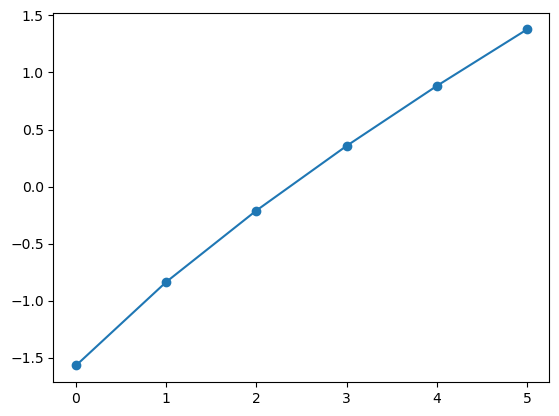

In [69]:
from sklearn.preprocessing import PowerTransformer
import numpy as np

X = np.array([[1], [2], [3], [4], [5], [6]])  # Ваши данные

pt = PowerTransformer(method='box-cox')  # выбираем метод
X_trans = pt.fit_transform(X)  # учим и преобразуем

print(X_trans)
plt.plot(X_trans, marker='o')